# Luxe — Evaluation Runner (Fixed)
- All 6 tests on the fixed 20-image eval set
- **Fixes applied:** SegFormer mask generation (no all-ones fallback), fine-tuned VAE injection, correct CLIP semantic test, correct Test 5 masks
- Safety checker disabled (standard adversarial ML research practice)
- Seed: `torch.manual_seed(42)` for reproducibility
- Outputs: `results/eval_results.csv` + `results/grids/`

In [14]:
import os
os.system('pip install -q PyDrive2 lpips diffusers transformers accelerate safetensors scikit-image')
os.system('pip install -q git+https://github.com/openai/CLIP.git')

from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
print('✅ Drive authenticated')

✅ Drive authenticated


In [15]:
import subprocess, sys

REPO_PATH = '/kaggle/working/Luxe'
if not os.path.exists(REPO_PATH):
    subprocess.run(['git', 'clone', 'https://github.com/nabirakhan/luxe', REPO_PATH], check=True)
else:
    subprocess.run(['git', '-C', REPO_PATH, 'pull'], check=True)

with open(f'{REPO_PATH}/backend/pgd_modification.py', 'r') as f:
    content = f.read()
content = content.replace(
    'clip_model, _ = clip.load("ViT-L/14", device=self._device)',
    'clip_model, _ = clip.load("ViT-B/32", device=self._device)'
)
with open(f'{REPO_PATH}/backend/pgd_modification.py', 'w') as f:
    f.write(content)

sys.path.insert(0, f'{REPO_PATH}/backend')
print('✅ Repo ready')

Already up to date.
✅ Repo ready


In [16]:
CKPT_FOLDER_ID    = '18cprgjVtQcEm4B9g-S9N0wpjHziGlUS5'
RESULTS_FOLDER_ID = '1hjqlvF6yq-czKy91lbOBiwa0QsvJp1Wo'   # your own folder

CKPT_LOCAL  = '/kaggle/working/checkpoints'
RESULTS_DIR = '/kaggle/working/results'
os.makedirs(CKPT_LOCAL, exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/grids', exist_ok=True)
print('✅ Paths ready')

✅ Paths ready


In [17]:
NEEDED = ['cloak_unet.pth', 'segformer_lip.pth', 'sd_inpaint_vae.pth', 'ipp_vae.pth', 'ip_adapter.pth']

file_list = drive.ListFile(
    {'q': f"'{CKPT_FOLDER_ID}' in parents and trashed=false"}
).GetList()

for fname in NEEDED:
    local = os.path.join(CKPT_LOCAL, fname)
    if os.path.exists(local):
        print(f'  ✅ Already local: {fname}')
        continue
    match = [f for f in file_list if f['title'] == fname]
    if match:
        print(f'  Downloading {fname}...')
        match[0].GetContentFile(local)
        print(f'  ✅ {fname} downloaded')
    else:
        print(f'  ⚠️  NOT FOUND ON DRIVE: {fname}')

print('\nCheckpoint status:')
for fname in NEEDED:
    exists = os.path.exists(os.path.join(CKPT_LOCAL, fname))
    print(f'  {"✅" if exists else "❌"} {fname}')

  ✅ Already local: cloak_unet.pth
  ✅ Already local: segformer_lip.pth
  ✅ Already local: sd_inpaint_vae.pth
  ✅ Already local: ipp_vae.pth
  ✅ Already local: ip_adapter.pth

Checkpoint status:
  ✅ cloak_unet.pth
  ✅ segformer_lip.pth
  ✅ sd_inpaint_vae.pth
  ✅ ipp_vae.pth
  ✅ ip_adapter.pth


In [18]:
import zipfile

IMG_ZIP_ID     = '1VDmSzYS4jeH-45c7JMVF22bTrqzdW0Gp'
HIGHRES_ZIP_ID = '1wNZY1blOmOThcCuCRyD36HsncKp4z5wM'

downloads = [
    (IMG_ZIP_ID,     '/kaggle/working/deepfashion_img.zip',     '/kaggle/working/deepfashion/img/'),
    (HIGHRES_ZIP_ID, '/kaggle/working/deepfashion_highres.zip', '/kaggle/working/deepfashion/seg/'),
]

for file_id, local_zip, extract_to in downloads:
    if os.path.exists(extract_to):
        print(f'✅ Already extracted: {extract_to}')
        continue
    print(f'Downloading {local_zip}...')
    f = drive.CreateFile({'id': file_id})
    f.GetContentFile(local_zip)
    print(f'  Downloaded. Unzipping...')
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(local_zip, 'r') as z:
        z.extractall(extract_to)
    os.remove(local_zip)
    print(f'  ✅ Done → {extract_to}')

✅ Already extracted: /kaggle/working/deepfashion/img/
✅ Already extracted: /kaggle/working/deepfashion/seg/


In [19]:
CKPT_BACKEND = f'{REPO_PATH}/backend/checkpoints'
os.makedirs(CKPT_BACKEND, exist_ok=True)

for fname in NEEDED:
    src = os.path.join(CKPT_LOCAL, fname)
    dst = os.path.join(CKPT_BACKEND, fname)
    if os.path.exists(src) and not os.path.exists(dst):
        os.symlink(src, dst)
        print(f'  🔗 Linked {fname}')
    elif os.path.exists(dst):
        print(f'  ✅ Already linked: {fname}')
    else:
        print(f'  ⚠️  Source missing: {fname}')

print('✅ Checkpoints linked')

  ✅ Already linked: cloak_unet.pth
  ✅ Already linked: segformer_lip.pth
  ✅ Already linked: sd_inpaint_vae.pth
  ✅ Already linked: ipp_vae.pth
  ✅ Already linked: ip_adapter.pth
✅ Checkpoints linked


In [20]:
import torch
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

os.chdir(f'{REPO_PATH}/backend')
print(f'✅ Working dir: {os.getcwd()}')

✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
✅ Working dir: /kaggle/working/Luxe/backend


In [21]:
from protect import Protector

print('Loading Protector (SegFormer loads at init ~180MB)...')
protector = Protector()

status = protector.checkpoint_status()
print('\nCheckpoint status:')
for k, v in status.items():
    print(f'  {"✅" if v else "❌"} {k}')

if not status.get('cloak_unet'):
    print('\n❌ cloak_unet.pth missing — eval will use slow PGD fallback (~90s/image)')
else:
    print('\n✅ All checkpoints ready — U-Net fast path active')

Loading Protector (SegFormer loads at init ~180MB)...


/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                    
------------------------------+----------+----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([20])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([20, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



Checkpoint status:
  ✅ segformer_lip
  ✅ cloak_unet
  ✅ sd_inpaint_vae
  ✅ ipp_vae
  ✅ ip_adapter

✅ All checkpoints ready — U-Net fast path active


In [22]:
import io, numpy as np
from pathlib import Path
from PIL import Image

IMG_DIR   = '/kaggle/working/deepfashion/img'   # fixed from /content/
MASK_DIR  = 'data/eval/masks'
EVAL_LIST = 'data/eval_filenames.txt'
os.makedirs(MASK_DIR, exist_ok=True)

with open(EVAL_LIST) as f:
    names = [l.strip() for l in f if l.strip()]

images = []
for name in names:
    path = Path(IMG_DIR) / name
    img = Image.open(path).convert('RGB').resize((512, 512), Image.LANCZOS)
    images.append((name, img))

print(f'✅ Loaded {len(images)} eval images')

✅ Loaded 20 eval images


In [23]:
# ── Generate cloaked images + SegFormer masks ───────────────────────────────
# FIX: replaced all-ones mask fallback with live SegFormer inference
# All-ones mask causes inpainting to regenerate the entire image from scratch,
# making disruption measurements meaningless (0.0000 was caused by this).

from segformer import SegFormerMask

print('Loading SegFormer for mask generation...')
seg_masker = SegFormerMask()
print('✅ SegFormer loaded')

print(f'Generating cloaked images + clothing masks for {len(images)} eval images...')
cloaked_images = []
masks = []
mask_coverage = []  # track % pixels masked per image for diagnostics

for i, (name, pil_img) in enumerate(images):
    # Cloak the image
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG')
    x_orig_t, delta_t, mask_pgd = protector.protect_pgd_only(buf.getvalue(), mode='full')
    x_cloaked_t = (x_orig_t + delta_t).clamp(0, 1)
    cloaked_np  = (x_cloaked_t.permute(1,2,0).numpy() * 255).astype(np.uint8)
    cloaked_pil = Image.fromarray(cloaked_np)
    path_used   = 'pgd'
    cloaked_images.append((name, cloaked_pil))

    # Generate mask via SegFormer — clothing + skin regions
    arr = np.array(pil_img, dtype=np.float32) / 255.0
    t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)
    with torch.no_grad():
        mask = seg_masker.generate_mask(t)  # [1, 512, 512] float in [0,1]
    masks.append(mask)

    # Diagnostics
    coverage = float(mask.mean()) * 100
    mask_coverage.append(coverage)

    # Save mask for reproducibility
    mask_path = Path(MASK_DIR) / (Path(name).stem + '_mask.png')
    Image.fromarray((mask.squeeze().numpy() * 255).astype(np.uint8)).save(mask_path)

    print(f'  [{i+1}/{len(images)}] {name} — {path_used} | mask coverage: {coverage:.1f}%')

avg_coverage = sum(mask_coverage) / len(mask_coverage)
print(f'\n✅ All {len(cloaked_images)} images cloaked')
print(f'   Avg mask coverage: {avg_coverage:.1f}% of image pixels')
if avg_coverage < 5:
    print('   ⚠️  WARNING: Very low mask coverage — SegFormer may not be detecting clothing correctly')
elif avg_coverage > 80:
    print('   ⚠️  WARNING: Very high mask coverage — masks may be too broad')
else:
    print('   ✅ Mask coverage looks reasonable')


Loading SegFormer for mask generation...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                    
------------------------------+----------+----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([20])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([20, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ SegFormer loaded
Generating cloaked images + clothing masks for 20 eval images...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


...

  [16/20] img/WOMEN/Sweaters/id_00002583/04_7_additional.jpg — pgd | mask coverage: 21.3%


  [17/20] img/WOMEN/Sweaters/id_00006734/10_4_full.jpg — pgd | mask coverage: 10.9%


  [18/20] img/WOMEN/Tees_Tanks/id_00001456/02_1_front.jpg — pgd | mask coverage: 14.5%


  [19/20] img/WOMEN/Tees_Tanks/id_00002901/02_7_additional.jpg — pgd | mask coverage: 52.9%


  [20/20] img/WOMEN/Tees_Tanks/id_00007406/06_7_additional.jpg — pgd | mask coverage: 25.9%

✅ All 20 images cloaked
   Avg mask coverage: 26.6% of image pixels
   ✅ Mask coverage looks reasonable


In [24]:
from metrics import clip_cosine_sim, lpips_score, psnr_score, ssim_score

# ── Test 1: Imperceptibility (LPIPS / SSIM / PSNR) ───────────────────────────
print('Test 1: Imperceptibility...')
rows_t1 = []
for (name, orig), (_, cloaked) in zip(images, cloaked_images):
    l = lpips_score(orig, cloaked)
    s = ssim_score(orig, cloaked)
    p = psnr_score(orig, cloaked)
    rows_t1.append({'test': '1_imperceptibility', 'image': name, 'lpips': l, 'ssim': s, 'psnr': p})
    print(f'  {name}: LPIPS={l:.4f} SSIM={s:.4f} PSNR={p:.2f}')

avg_lpips = sum(r['lpips'] for r in rows_t1) / len(rows_t1)
avg_ssim  = sum(r['ssim']  for r in rows_t1) / len(rows_t1)
avg_psnr  = sum(r['psnr']  for r in rows_t1) / len(rows_t1)
print(f'\n  AVG — LPIPS={avg_lpips:.4f} (target <0.05) | SSIM={avg_ssim:.4f} (target >0.95) | PSNR={avg_psnr:.2f} (target >35)')
print('✅ Test 1 done')

Test 1: Imperceptibility...
  img/MEN/Pants/id_00000954/01_7_additional.jpg: LPIPS=0.0513 SSIM=0.9587 PSNR=40.03
  img/MEN/Shirts_Polos/id_00000240/01_3_back.jpg: LPIPS=0.0763 SSIM=0.9398 PSNR=36.12
  img/MEN/Shorts/id_00001015/01_3_back.jpg: LPIPS=0.0464 SSIM=0.9650 PSNR=38.72
  img/MEN/Sweaters/id_00000289/02_6_flat.jpg: LPIPS=0.0872 SSIM=0.9281 PSNR=36.23
  img/MEN/Tees_Tanks/id_00002310/02_3_back.jpg: LPIPS=0.0612 SSIM=0.9562 PSNR=40.29
  img/WOMEN/Blouses_Shirts/id_00001086/02_1_front.jpg: LPIPS=0.0771 SSIM=0.9424 PSNR=38.53
  img/WOMEN/Blouses_Shirts/id_00001172/02_1_front.jpg: LPIPS=0.0885 SSIM=0.9255 PSNR=36.34
  img/WOMEN/Blouses_Shirts/id_00004322/01_2_side.jpg: LPIPS=0.0835 SSIM=0.9346 PSNR=37.47
  img/WOMEN/Blouses_Shirts/id_00005517/02_1_front.jpg: LPIPS=0.0802 SSIM=0.9438 PSNR=35.57
  img/WOMEN/Blouses_Shirts/id_00006389/07_1_front.jpg: LPIPS=0.0878 SSIM=0.9144 PSNR=36.42
  img/WOMEN/Blouses_Shirts/id_00007354/01_1_front.jpg: LPIPS=0.0749 SSIM=0.9483 PSNR=36.47
  img/WOME

In [28]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
from diffusers import StableDiffusionInpaintPipeline, StableDiffusionXLInpaintPipeline
import gc

login(token=UserSecretsClient().get_secret('HF TOKEN'))
print('HF authenticated')

def sd_inpaint(pipe, pil_img, mask_pil, prompt):
    gen = torch.Generator(device=device).manual_seed(42)
    return pipe(prompt=prompt, image=pil_img, mask_image=mask_pil, generator=gen).images[0]

print('Test 2a: Nudification disruption...')
prompt_nudify = 'nude person'
rows_t2a = []

# SD v1.5 white-box
print('  Loading SD v1.5 (white-box)...')
pipe_sd15 = StableDiffusionInpaintPipeline.from_pretrained(
    'runwayml/stable-diffusion-inpainting',
    torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False,
).to(device)
vae_path = f'{CKPT_LOCAL}/sd_inpaint_vae.pth'
if os.path.exists(vae_path):
    state_dict = torch.load(vae_path, map_location=device)
    if hasattr(state_dict, 'items'):
        pipe_sd15.vae.load_state_dict(state_dict, strict=False)
    else:
        pipe_sd15.vae = state_dict.to(device=device, dtype=torch.float16)
    print('  Fine-tuned VAE weights injected — white-box test')
else:
    print('  sd_inpaint_vae.pth not found — vanilla SD v1.5')
for (name, orig), (_, cloaked), mask in zip(images, cloaked_images, masks):
    mask_pil    = Image.fromarray((mask.squeeze().numpy()*255).astype(np.uint8)).convert('L')
    out_orig    = sd_inpaint(pipe_sd15, orig,    mask_pil, prompt_nudify)
    out_cloaked = sd_inpaint(pipe_sd15, cloaked, mask_pil, prompt_nudify)
    disruption  = lpips_score(out_orig, out_cloaked)
    rows_t2a.append({'test':'2a_nudify_disruption','image':name,'model':'sd15_wb','lpips_disruption':disruption})
    print(f'    {name} [sd15_wb] disruption={disruption:.4f}')
# Unload before loading next model
pipe_sd15.to('cpu'); del pipe_sd15; gc.collect(); torch.cuda.empty_cache()
print('  SD v1.5 unloaded')

# SD v2 grey-box
print('  Loading SD v2 (grey-box)...')
pipe_sd2 = StableDiffusionInpaintPipeline.from_pretrained(
    'sd2-community/stable-diffusion-2-inpainting',
    torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False,
).to(device)
for (name, orig), (_, cloaked), mask in zip(images, cloaked_images, masks):
    mask_pil    = Image.fromarray((mask.squeeze().numpy()*255).astype(np.uint8)).convert('L')
    out_orig    = sd_inpaint(pipe_sd2, orig,    mask_pil, prompt_nudify)
    out_cloaked = sd_inpaint(pipe_sd2, cloaked, mask_pil, prompt_nudify)
    disruption  = lpips_score(out_orig, out_cloaked)
    rows_t2a.append({'test':'2a_nudify_disruption','image':name,'model':'sd2_gb','lpips_disruption':disruption})
    print(f'    {name} [sd2_gb] disruption={disruption:.4f}')
pipe_sd2.to('cpu'); del pipe_sd2; gc.collect(); torch.cuda.empty_cache()
print('  SD v2 unloaded')

# SDXL grey-box
print('  Loading SDXL (grey-box)...')
pipe_xl = StableDiffusionXLInpaintPipeline.from_pretrained(
    'diffusers/stable-diffusion-xl-1.0-inpainting-0.1',
    torch_dtype=torch.float16,
).to(device)
for (name, orig), (_, cloaked), mask in zip(images, cloaked_images, masks):
    mask_pil    = Image.fromarray((mask.squeeze().numpy()*255).astype(np.uint8)).convert('L')
    out_orig    = sd_inpaint(pipe_xl, orig,    mask_pil, prompt_nudify)
    out_cloaked = sd_inpaint(pipe_xl, cloaked, mask_pil, prompt_nudify)
    disruption  = lpips_score(out_orig, out_cloaked)
    rows_t2a.append({'test':'2a_nudify_disruption','image':name,'model':'sdxl_gb','lpips_disruption':disruption})
    print(f'    {name} [sdxl_gb] disruption={disruption:.4f}')
pipe_xl.to('cpu'); del pipe_xl; gc.collect(); torch.cuda.empty_cache()
print('  SDXL unloaded')

avg_sd15 = sum(r['lpips_disruption'] for r in rows_t2a if r['model']=='sd15_wb') / len(images)
avg_sd2  = sum(r['lpips_disruption'] for r in rows_t2a if r['model']=='sd2_gb')  / len(images)
avg_xl   = sum(r['lpips_disruption'] for r in rows_t2a if r['model']=='sdxl_gb') / len(images)
print(f'\n  AVG [sd15_wb]: {avg_sd15:.4f}  (white-box)')
print(f'  AVG [sd2_gb]:  {avg_sd2:.4f}  (grey-box)')
print(f'  AVG [sdxl_gb]: {avg_xl:.4f}  (grey-box)')
print('Test 2a done')

HF authenticated
Test 2a: Nudification disruption...
  Loading SD v1.5 (white-box)...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--run

  Fine-tuned VAE weights injected — white-box test


...

  0%|          | 0/49 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.


    img/WOMEN/Tees_Tanks/id_00007406/06_7_additional.jpg [sdxl_gb] disruption=0.1037


Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

  SDXL unloaded

  AVG [sd15_wb]: 0.1638  (white-box)
  AVG [sd2_gb]:  0.1771  (grey-box)
  AVG [sdxl_gb]: 0.1254  (grey-box)
Test 2a done


In [29]:
# ── Test 2b: IPP outfit-swap disruption ──────────────────────────────────────
print('Test 2b: IPP outfit-swap disruption...')
rows_t2b = []

print('  Loading IPP with fine-tuned VAE...')
pipe_ipp = StableDiffusionInpaintPipeline.from_pretrained(
    'runwayml/stable-diffusion-inpainting',
    torch_dtype=torch.float16,
    safety_checker=None, requires_safety_checker=False,
).to(device)

ipp_vae_path = f'{CKPT_LOCAL}/ipp_vae.pth'
if os.path.exists(ipp_vae_path):
    state_dict = torch.load(ipp_vae_path, map_location=device)
    if hasattr(state_dict, 'items'):
        pipe_ipp.vae.load_state_dict(state_dict, strict=False)
    else:
        pipe_ipp.vae = state_dict.to(device=device, dtype=torch.float16)
    print('  ✅ Fine-tuned IPP VAE injected')
else:
    print('  ⚠️  ipp_vae.pth not found — running vanilla')

prompt_swap = 'change the outfit to a blue dress'
for (name, orig), (_, cloaked), mask in zip(images, cloaked_images, masks):
    mask_pil = Image.fromarray((mask.squeeze().numpy() * 255).astype(np.uint8)).convert('L')
    out_orig    = sd_inpaint(pipe_ipp, orig,    mask_pil, prompt_swap)
    out_cloaked = sd_inpaint(pipe_ipp, cloaked, mask_pil, prompt_swap)
    disruption  = lpips_score(out_orig, out_cloaked)
    rows_t2b.append({'test': '2b_ipp_disruption', 'image': name, 'lpips_disruption': disruption})
    print(f'  {name}: disruption={disruption:.4f}')

avg_t2b = sum(r['lpips_disruption'] for r in rows_t2b) / len(rows_t2b)
print(f'  AVG disruption: {avg_t2b:.4f} (target >0.60)')
pipe_ipp.to('cpu'); del pipe_ipp; gc.collect(); torch.cuda.empty_cache()
print('✅ Test 2b done')

Test 2b: IPP outfit-swap disruption...
  Loading IPP with fine-tuned VAE...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--run

  ✅ Fine-tuned IPP VAE injected


...

  0%|          | 0/50 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.


  img/WOMEN/Tees_Tanks/id_00007406/06_7_additional.jpg: disruption=0.0723
  AVG disruption: 0.1151 (target >0.60)


Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.


✅ Test 2b done


In [30]:
# ── Test 2c: SegFormer mIoU degradation (5-image qualitative) ────────────────
print('Test 2c: SegFormer mIoU (5 images)...')
from segformer import SegFormerMask
segformer = SegFormerMask()

rows_t2c = []
for (name, orig), (_, cloaked) in list(zip(images, cloaked_images))[:5]:
    def get_mask(pil_img):
        arr = np.array(pil_img, dtype=np.float32) / 255.0
        t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)
        return segformer.generate_mask(t).squeeze().numpy()

    mask_orig    = get_mask(orig)
    mask_cloaked = get_mask(cloaked)
    intersection = (mask_orig * mask_cloaked).sum()
    union = np.clip(mask_orig + mask_cloaked, 0, 1).sum()
    iou = float(intersection / union) if union > 0 else 0.0
    rows_t2c.append({'test': '2c_segformer_miou', 'image': name, 'iou_cloaked_vs_original': iou})
    print(f'  {name}: IoU={iou:.4f}')

print('✅ Test 2c done')

Test 2c: SegFormer mIoU (5 images)...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                    
------------------------------+----------+----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([20])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([20, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  img/MEN/Pants/id_00000954/01_7_additional.jpg: IoU=0.9781
  img/MEN/Shirts_Polos/id_00000240/01_3_back.jpg: IoU=0.9934
  img/MEN/Shorts/id_00001015/01_3_back.jpg: IoU=0.9746
  img/MEN/Sweaters/id_00000289/02_6_flat.jpg: IoU=0.9744
  img/MEN/Tees_Tanks/id_00002310/02_3_back.jpg: IoU=0.9816
✅ Test 2c done


In [31]:
# ── Test 3: CLIP semantic disruption ────────────────────────────────────────
# FIX: original measured image-to-image similarity (always ~0.96 since images look alike)
# Correct measurement: does cloaking reduce CLIP's confidence in the image's true content?
# We measure similarity to a text description of what the image contains.
# A drop in sim_original → sim_cloaked means the AI understands the image less.

import clip as clip_lib

print('Loading CLIP ViT-B/32 for semantic test...')
clip_model_t3, clip_preprocess_t3 = clip_lib.load('ViT-B/32', device=device)
clip_model_t3.eval()

def clip_img_text_sim(pil_img, text):
    img_t = clip_preprocess_t3(pil_img).unsqueeze(0).to(device)
    txt_t = clip_lib.tokenize([text]).to(device)
    with torch.no_grad():
        img_feat = clip_model_t3.encode_image(img_t).float()
        txt_feat = clip_model_t3.encode_text(txt_t).float()
        img_feat /= img_feat.norm(dim=-1, keepdim=True)
        txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
    return float((img_feat * txt_feat).sum())

# Also keep old image-to-image similarity for completeness
def clip_img_img_sim(pil_a, pil_b):
    ta = clip_preprocess_t3(pil_a).unsqueeze(0).to(device)
    tb = clip_preprocess_t3(pil_b).unsqueeze(0).to(device)
    with torch.no_grad():
        fa = clip_model_t3.encode_image(ta).float()
        fb = clip_model_t3.encode_image(tb).float()
        fa /= fa.norm(dim=-1, keepdim=True)
        fb /= fb.norm(dim=-1, keepdim=True)
    return float((fa * fb).sum())

concept = 'a person wearing clothes'
print(f'Test 3: CLIP semantic disruption (concept: "{concept}")...')
rows_t3 = []

for (name, orig), (_, cloaked) in zip(images, cloaked_images):
    sim_orig    = clip_img_text_sim(orig,    concept)
    sim_cloaked = clip_img_text_sim(cloaked, concept)
    sim_img2img = clip_img_img_sim(orig, cloaked)  # kept for reference
    drop        = sim_orig - sim_cloaked
    rows_t3.append({
        'test':             '3_clip_semantic',
        'image':            name,
        'clip_sim_orig':    sim_orig,
        'clip_sim_cloaked': sim_cloaked,
        'semantic_drop':    drop,
        'clip_img2img':     sim_img2img,
    })
    print(f'  {name}: orig={sim_orig:.4f} → cloaked={sim_cloaked:.4f}  drop={drop:+.4f}')

avg_orig    = sum(r['clip_sim_orig']    for r in rows_t3) / len(rows_t3)
avg_cloaked = sum(r['clip_sim_cloaked'] for r in rows_t3) / len(rows_t3)
avg_drop    = sum(r['semantic_drop']    for r in rows_t3) / len(rows_t3)
avg_img2img = sum(r['clip_img2img']     for r in rows_t3) / len(rows_t3)
avg_sim     = avg_cloaked  # keep variable name for summary cell compatibility

print(f'\n  AVG original→concept:  {avg_orig:.4f}')
print(f'  AVG cloaked→concept:   {avg_cloaked:.4f}')
print(f'  AVG semantic drop:     {avg_drop:+.4f}  (positive = disruption working)')
print(f'  AVG img-to-img sim:    {avg_img2img:.4f}  (reference only — always high)')
print('✅ Test 3 done')


Loading CLIP ViT-B/32 for semantic test...
Test 3: CLIP semantic disruption (concept: "a person wearing clothes")...
  img/MEN/Pants/id_00000954/01_7_additional.jpg: orig=0.2302 → cloaked=0.2491  drop=-0.0190
  img/MEN/Shirts_Polos/id_00000240/01_3_back.jpg: orig=0.2331 → cloaked=0.2315  drop=+0.0016
  img/MEN/Shorts/id_00001015/01_3_back.jpg: orig=0.2318 → cloaked=0.2452  drop=-0.0134
  img/MEN/Sweaters/id_00000289/02_6_flat.jpg: orig=0.2152 → cloaked=0.2108  drop=+0.0044
  img/MEN/Tees_Tanks/id_00002310/02_3_back.jpg: orig=0.2516 → cloaked=0.2478  drop=+0.0038
  img/WOMEN/Blouses_Shirts/id_00001086/02_1_front.jpg: orig=0.2273 → cloaked=0.2513  drop=-0.0240
  img/WOMEN/Blouses_Shirts/id_00001172/02_1_front.jpg: orig=0.2275 → cloaked=0.2300  drop=-0.0025
  img/WOMEN/Blouses_Shirts/id_00004322/01_2_side.jpg: orig=0.2365 → cloaked=0.2254  drop=+0.0111
  img/WOMEN/Blouses_Shirts/id_00005517/02_1_front.jpg: orig=0.2444 → cloaked=0.2352  drop=+0.0093
  img/WOMEN/Blouses_Shirts/id_00006389/0

In [32]:
# ── Test 4: EOT robustness ────────────────────────────────────────────────────
print('Test 4: EOT robustness...')
from eot import EOTTransforms
eot = EOTTransforms()

transforms = [
    ('jpeg',       eot.jpeg_simulate),
    ('resize',     eot.random_resize),
    ('crop_pad',   eot.random_crop_pad),
    ('screenshot', eot.screenshot_simulate),
    ('color',      eot.color_jitter),
]

rows_t4 = []
for (name, orig), (_, cloaked) in zip(images, cloaked_images):
    orig_t    = torch.from_numpy(np.array(orig,    dtype=np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0)
    cloaked_t = torch.from_numpy(np.array(cloaked, dtype=np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0)
    for t_name, t_fn in transforms:
        with torch.no_grad():
            aug = t_fn(cloaked_t).squeeze(0)
        aug_pil = Image.fromarray((aug.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
        l = lpips_score(orig, aug_pil)
        s = ssim_score(orig, aug_pil)
        p = psnr_score(orig, aug_pil)
        rows_t4.append({'test': '4_eot_robustness', 'image': name, 'transform': t_name, 'lpips': l, 'ssim': s, 'psnr': p})
    print(f'  {name}: done')

print('✅ Test 4 done')

Test 4: EOT robustness...
  img/MEN/Pants/id_00000954/01_7_additional.jpg: done
  img/MEN/Shirts_Polos/id_00000240/01_3_back.jpg: done
  img/MEN/Shorts/id_00001015/01_3_back.jpg: done
  img/MEN/Sweaters/id_00000289/02_6_flat.jpg: done
  img/MEN/Tees_Tanks/id_00002310/02_3_back.jpg: done
  img/WOMEN/Blouses_Shirts/id_00001086/02_1_front.jpg: done
  img/WOMEN/Blouses_Shirts/id_00001172/02_1_front.jpg: done
  img/WOMEN/Blouses_Shirts/id_00004322/01_2_side.jpg: done
  img/WOMEN/Blouses_Shirts/id_00005517/02_1_front.jpg: done
  img/WOMEN/Blouses_Shirts/id_00006389/07_1_front.jpg: done
  img/WOMEN/Blouses_Shirts/id_00007354/01_1_front.jpg: done
  img/WOMEN/Blouses_Shirts/id_00007416/03_7_additional.jpg: done
  img/WOMEN/Dresses/id_00005937/02_3_back.jpg: done
  img/WOMEN/Jackets_Coats/id_00002339/02_7_additional.jpg: done
  img/WOMEN/Pants/id_00000315/02_1_front.jpg: done
  img/WOMEN/Sweaters/id_00002583/04_7_additional.jpg: done
  img/WOMEN/Sweaters/id_00006734/10_4_full.jpg: done
  img/WOM

In [33]:
# ── Test 5: Grey-box qualitative (5 images) ──────────────────────────────
from diffusers import StableDiffusionInpaintPipeline, StableDiffusionXLInpaintPipeline
import gc

print('Test 5: Grey-box qualitative (5 images)...')
prompt_swap = 'change the outfit to a blue dress'
rows_t5 = []
five = list(zip(images, cloaked_images, masks))[:5]

# ── SD v1.5 ───────────────────────────────────────────────────────────────
print('  Loading SD v1.5 for Test 5...')
pipe_sd15 = StableDiffusionInpaintPipeline.from_pretrained(
    'runwayml/stable-diffusion-inpainting',
    torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False,
).to(device)

for (name, orig), (_, cloaked), mask in five:
    mask_pil    = Image.fromarray((mask.squeeze().numpy()*255).astype(np.uint8)).convert('L')
    out_orig    = sd_inpaint(pipe_sd15, orig,    mask_pil, prompt_swap)
    out_cloaked = sd_inpaint(pipe_sd15, cloaked, mask_pil, prompt_swap)
    disruption  = lpips_score(out_orig, out_cloaked)
    grid = Image.new('RGB', (1024, 512))
    grid.paste(out_orig, (0, 0)); grid.paste(out_cloaked, (512, 0))
    save_path = f'{RESULTS_DIR}/grids/test5_{Path(name).stem}_sd15_wb.png'
    grid.save(save_path)
    rows_t5.append({'test':'5_greybox','image':name,'model':'sd15_wb',
                    'lpips_disruption':disruption,'saved':True})
    print(f'  {name} [sd15_wb] disruption={disruption:.4f}')

pipe_sd15.to('cpu'); del pipe_sd15; gc.collect(); torch.cuda.empty_cache()
print('  SD v1.5 unloaded')

# ── SDXL ──────────────────────────────────────────────────────────────────
print('  Loading SDXL for Test 5...')
pipe_xl = StableDiffusionXLInpaintPipeline.from_pretrained(
    'diffusers/stable-diffusion-xl-1.0-inpainting-0.1',
    torch_dtype=torch.float16,
).to(device)

for (name, orig), (_, cloaked), mask in five:
    mask_pil    = Image.fromarray((mask.squeeze().numpy()*255).astype(np.uint8)).convert('L')
    out_orig    = sd_inpaint(pipe_xl, orig,    mask_pil, prompt_swap)
    out_cloaked = sd_inpaint(pipe_xl, cloaked, mask_pil, prompt_swap)
    disruption  = lpips_score(out_orig, out_cloaked)
    grid = Image.new('RGB', (1024, 512))
    grid.paste(out_orig, (0, 0)); grid.paste(out_cloaked, (512, 0))
    save_path = f'{RESULTS_DIR}/grids/test5_{Path(name).stem}_sdxl_vanilla.png'
    grid.save(save_path)
    rows_t5.append({'test':'5_greybox','image':name,'model':'sdxl_vanilla',
                    'lpips_disruption':disruption,'saved':True})
    print(f'  {name} [sdxl_vanilla] disruption={disruption:.4f}')

pipe_xl.to('cpu'); del pipe_xl; gc.collect(); torch.cuda.empty_cache()
print('  SDXL unloaded')

# Summary
for mname in ['sd15_wb', 'sdxl_vanilla']:
    vals = [r['lpips_disruption'] for r in rows_t5 if r['model']==mname]
    if vals: print(f'  AVG [{mname}]: {sum(vals)/len(vals):.4f}')

# Set to None so downstream cells don't try to use them
pipe_sd15 = None
pipe_xl   = None

print('Test 5 done')

Test 5: Grey-box qualitative (5 images)...
  Loading SD v1.5 for Test 5...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--run

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/49 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.


  img/MEN/Tees_Tanks/id_00002310/02_3_back.jpg [sdxl_vanilla] disruption=0.0997


Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

  SDXL unloaded
  AVG [sd15_wb]: 0.1189
  AVG [sdxl_vanilla]: 0.1146
Test 5 done


In [34]:
import time

print('Test 6: Timing (warmup + 20 images)...')

dummy_buf = io.BytesIO()
Image.new('RGB', (512, 512)).save(dummy_buf, format='JPEG')
protector.protect(dummy_buf.getvalue(), mode='full')
print('  Warmup done')

times = []
for name, pil_img in images:
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG')
    t0 = time.perf_counter()
    protector.protect(buf.getvalue(), mode='full')
    elapsed = time.perf_counter() - t0
    times.append(elapsed)
    print(f'  {name}: {elapsed:.2f}s')

rows_t6 = [{
    'test':   '6_timing',
    'mean_s': float(np.mean(times)),
    'std_s':  float(np.std(times)),
    'min_s':  float(np.min(times)),
    'max_s':  float(np.max(times)),
}]
print(f'\n  Timing — mean={np.mean(times):.2f}s  std={np.std(times):.2f}s  min={np.min(times):.2f}s  max={np.max(times):.2f}s')
print(f'  (target: <10s on GPU)')
print('✅ Test 6 done')

Test 6: Timing (warmup + 20 images)...
  Warmup done
  img/MEN/Pants/id_00000954/01_7_additional.jpg: 0.17s
  img/MEN/Shirts_Polos/id_00000240/01_3_back.jpg: 0.15s
  img/MEN/Shorts/id_00001015/01_3_back.jpg: 0.14s
  img/MEN/Sweaters/id_00000289/02_6_flat.jpg: 0.14s
  img/MEN/Tees_Tanks/id_00002310/02_3_back.jpg: 0.14s
  img/WOMEN/Blouses_Shirts/id_00001086/02_1_front.jpg: 0.14s
  img/WOMEN/Blouses_Shirts/id_00001172/02_1_front.jpg: 0.14s
  img/WOMEN/Blouses_Shirts/id_00004322/01_2_side.jpg: 0.14s
  img/WOMEN/Blouses_Shirts/id_00005517/02_1_front.jpg: 0.14s
  img/WOMEN/Blouses_Shirts/id_00006389/07_1_front.jpg: 0.14s
  img/WOMEN/Blouses_Shirts/id_00007354/01_1_front.jpg: 0.14s
  img/WOMEN/Blouses_Shirts/id_00007416/03_7_additional.jpg: 0.15s
  img/WOMEN/Dresses/id_00005937/02_3_back.jpg: 0.13s
  img/WOMEN/Jackets_Coats/id_00002339/02_7_additional.jpg: 0.16s
  img/WOMEN/Pants/id_00000315/02_1_front.jpg: 0.14s
  img/WOMEN/Sweaters/id_00002583/04_7_additional.jpg: 0.14s
  img/WOMEN/Sweater

In [35]:
import csv
import numpy as np

all_rows = rows_t1 + rows_t2a + rows_t2b + rows_t2c + rows_t3 + rows_t4 + rows_t5 + rows_t6

out_path = f'{RESULTS_DIR}/eval_results.csv'
keys = sorted({k for row in all_rows for k in row})
with open(out_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=keys)
    writer.writeheader()
    writer.writerows(all_rows)

print(f'✅ Results written to {out_path}')
print(f'   {len(all_rows)} rows across all tests')

# ── Compute averages safely ───────────────────────────────────────────────
avg_sd15 = sum(r['lpips_disruption'] for r in rows_t2a if r['model']=='sd15_wb') / len(images)
avg_sd2  = sum(r['lpips_disruption'] for r in rows_t2a if r['model']=='sd2_gb' and r['lpips_disruption'] is not None) / max(1, sum(1 for r in rows_t2a if r['model']=='sd2_gb' and r['lpips_disruption'] is not None))
avg_xl   = sum(r['lpips_disruption'] for r in rows_t2a if r['model']=='sdxl_gb') / len(images)
t2b_vals = [r['lpips_disruption'] for r in rows_t2b if r.get('lpips_disruption') is not None]
avg_t2b  = sum(t2b_vals) / len(t2b_vals) if t2b_vals else float('nan')
t2c_vals = [r['iou_cloaked_vs_original'] for r in rows_t2c]
avg_t2c  = sum(t2c_vals) / len(t2c_vals) if t2c_vals else float('nan')

print('\n' + '='*60)
print('EVAL SUMMARY')
print('='*60)
print(f'Test 1  LPIPS:              {avg_lpips:.4f}  (target <0.05)  {"✅" if avg_lpips < 0.05 else "❌"}')
print(f'Test 1  SSIM:               {avg_ssim:.4f}  (target >0.95)  {"✅" if avg_ssim > 0.95 else "❌"}')
print(f'Test 1  PSNR:               {avg_psnr:.2f} dB  (target >35)  {"✅" if avg_psnr > 35 else "❌"}')
print(f'Test 2a [sd15_wb]:          {avg_sd15:.4f}  (white-box — target >0.75)')
print(f'Test 2a [sd2_gb]:           {avg_sd2:.4f}  (grey-box)')
print(f'Test 2a [sdxl_gb]:          {avg_xl:.4f}  (grey-box — target >0.15)')
print(f'Test 2b IPP outfit-swap:    {avg_t2b:.4f}  (target >0.60)' if not __import__('math').isnan(avg_t2b) else 'Test 2b:  skipped (checkpoint not found)')
print(f'Test 2c SegFormer IoU:      {avg_t2c:.4f}  (target <0.50 of baseline)' if not __import__('math').isnan(avg_t2c) else 'Test 2c:  no data')
print(f'Test 3  semantic drop:      {avg_drop:+.4f}  (positive = disruption working)')
print(f'Test 3  cloaked→concept:    {avg_cloaked:.4f}')
print(f'Test 6  Mean time:          {np.mean(times):.2f}s  (target <10s)  {"✅" if np.mean(times) < 10 else "❌"}')
print('='*60)


✅ Results written to /kaggle/working/results/eval_results.csv
   236 rows across all tests

EVAL SUMMARY
Test 1  LPIPS:              0.0767  (target <0.05)  ❌
Test 1  SSIM:               0.9412  (target >0.95)  ❌
Test 1  PSNR:               37.16 dB  (target >35)  ✅
Test 2a [sd15_wb]:          0.1638  (white-box — target >0.75)
Test 2a [sd2_gb]:           0.1771  (grey-box)
Test 2a [sdxl_gb]:          0.1254  (grey-box — target >0.15)
Test 2b IPP outfit-swap:    0.1151  (target >0.60)
Test 2c SegFormer IoU:      0.9804  (target <0.50 of baseline)
Test 3  semantic drop:      -0.0023  (positive = disruption working)
Test 3  cloaked→concept:    0.2341
Test 6  Mean time:          0.14s  (target <10s)  ✅


In [38]:
def upload_to_drive(local_path, folder_id, title=None):
    title = title or os.path.basename(local_path)
    try:
        existing = drive.ListFile(
            {'q': f"'{folder_id}' in parents and title='{title}' and trashed=false"}
        ).GetList()
        if existing:
            f = existing[0]; f.SetContentFile(local_path); f.Upload()
        else:
            f = drive.CreateFile({'title': title, 'parents': [{'id': folder_id}]})
            f.SetContentFile(local_path); f.Upload()
        print(f'  💾 Drive ↑ {title}')
    except Exception as e:
        print(f'  ⚠️  Upload failed for {title}: {e}')

upload_to_drive(out_path, RESULTS_FOLDER_ID, 'eval_results.csv')

for grid_file in Path(f'{RESULTS_DIR}/grids').glob('*.png'):
    upload_to_drive(str(grid_file), RESULTS_FOLDER_ID, grid_file.name)

print('✅ All results uploaded to Drive')

  ⚠️  Upload failed for eval_results.csv: <HttpError 404 when requesting None returned "File not found: 1hjqlvF6yq-czKy91lbOBiwa0QsvJp1Wo". Details: "[{'message': 'File not found: 1hjqlvF6yq-czKy91lbOBiwa0QsvJp1Wo', 'domain': 'global', 'reason': 'notFound', 'location': 'file', 'locationType': 'other'}]">
  ⚠️  Upload failed for test5_02_6_flat_sd15_wb.png: <HttpError 404 when requesting None returned "File not found: 1hjqlvF6yq-czKy91lbOBiwa0QsvJp1Wo". Details: "[{'message': 'File not found: 1hjqlvF6yq-czKy91lbOBiwa0QsvJp1Wo', 'domain': 'global', 'reason': 'notFound', 'location': 'file', 'locationType': 'other'}]">
  ⚠️  Upload failed for test5_01_3_back_sdxl_vanilla.png: <HttpError 404 when requesting None returned "File not found: 1hjqlvF6yq-czKy91lbOBiwa0QsvJp1Wo". Details: "[{'message': 'File not found: 1hjqlvF6yq-czKy91lbOBiwa0QsvJp1Wo', 'domain': 'global', 'reason': 'notFound', 'location': 'file', 'locationType': 'other'}]">
  ⚠️  Upload failed for test5_01_7_additional_sdxl_vani

In [39]:
RESULTS_FOLDER_ID = '10ciUM2xqFO33xq3BZBZW9Fupn3ILgQtv'

from pathlib import Path

csv = Path(f'{RESULTS_DIR}/eval_results.csv')
if csv.exists():
    upload_to_drive(str(csv), RESULTS_FOLDER_ID, 'eval_results.csv')

pngs = sorted(Path(f'{RESULTS_DIR}/grids').glob('*.png'))
print(f'Uploading {len(pngs)} PNG files...')
for p in pngs:
    upload_to_drive(str(p), RESULTS_FOLDER_ID, p.name)

print(f'Done — {len(pngs)+1} files uploaded')

  💾 Drive ↑ eval_results.csv
Uploading 8 PNG files...
  💾 Drive ↑ test5_01_3_back_sd15_wb.png
  💾 Drive ↑ test5_01_3_back_sdxl_vanilla.png
  💾 Drive ↑ test5_01_7_additional_sd15_wb.png
  💾 Drive ↑ test5_01_7_additional_sdxl_vanilla.png
  💾 Drive ↑ test5_02_3_back_sd15_wb.png
  💾 Drive ↑ test5_02_3_back_sdxl_vanilla.png
  💾 Drive ↑ test5_02_6_flat_sd15_wb.png
  💾 Drive ↑ test5_02_6_flat_sdxl_vanilla.png
Done — 9 files uploaded


In [37]:
from google.colab import auth
from oauth2client.client import GoogleCredentials
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
print('Reauthed OK')

Reauthed OK


In [ ]:
from google.oauth2.credentials import Credentials
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
from kaggle_secrets import UserSecretsClient
import json

# Get token from Kaggle secrets — add "GOOGLE_TOKEN" as a Kaggle secret
# with your OAuth token, OR just download files directly instead

# SIMPLEST FIX: just download the files from Kaggle directly
print('Files saved locally at:')
print(f'  {out_path}')
for grid_file in Path(f'{RESULTS_DIR}/grids').glob('*.png'):
    print(f'  {grid_file}')
print()
print('To get these files:')
print('  1. Kaggle notebook → Output tab (right side panel)')
print('  2. All files in /kaggle/working/ are downloadable there')
print('✅ Done')

In [40]:
# ── PGD TEST: runs REAL PGD against your fine-tuned VAE ──────────────────
import torch, io
import numpy as np
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# Load your fine-tuned SD VAE (same checkpoint already downloaded)
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    subfolder="vae"
).to(DEVICE)

# Inject your fine-tuned weights if the checkpoint exists
import os
sd_ckpt = '/kaggle/working/checkpoints/sd_inpaint_vae.pth'
if os.path.exists(sd_ckpt):
    vae.load_state_dict(torch.load(sd_ckpt, map_location=DEVICE))
    print('✅ Fine-tuned VAE loaded')
else:
    print('⚠️  Using vanilla VAE (fine-tuned checkpoint not found)')

vae.eval()
print('✅ VAE ready')

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


✅ Fine-tuned VAE loaded
✅ VAE ready


In [41]:
def pgd_attack_vae(image_pil, vae, device, epsilon=8/255, alpha=1/255, steps=40):
    import torchvision.transforms as T
    import lpips

    loss_fn = lpips.LPIPS(net='alex').to(device)

    transform = T.Compose([T.Resize((512, 512)), T.ToTensor()])
    x_orig = transform(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        latent_orig = vae.encode(x_orig * 2 - 1).latent_dist.mean

    delta = torch.zeros_like(x_orig).uniform_(-epsilon, epsilon).to(device)
    delta.requires_grad_(True)

    for step in range(steps):
        x_adv = torch.clamp(x_orig + delta, 0, 1)
        latent_adv = vae.encode(x_adv * 2 - 1).latent_dist.mean
        loss = -torch.mean((latent_adv - latent_orig) ** 2)
        loss.backward()

        with torch.no_grad():
            delta.data = delta.data - alpha * delta.grad.sign()
            delta.data = torch.clamp(delta.data, -epsilon, epsilon)
            delta.data = torch.clamp(x_orig + delta.data, 0, 1) - x_orig

        delta.grad.zero_()

        if (step + 1) % 10 == 0:
            print(f'  Step {step+1}/{steps} | latent dist: {-loss.item():.4f}')

    # ── FREE MEMORY before final measurement ──────────────────────────────
    torch.cuda.empty_cache()

    x_cloaked = torch.clamp(x_orig + delta.detach(), 0, 1)

    # Measure visual LPIPS in float32 on CPU to avoid OOM
    with torch.no_grad():
        x_orig_cpu    = x_orig.float().cpu()
        x_cloaked_cpu = x_cloaked.float().cpu()
        loss_fn_cpu   = lpips.LPIPS(net='alex')   # CPU instance
        visual_score  = loss_fn_cpu(
            x_orig_cpu * 2 - 1,
            x_cloaked_cpu * 2 - 1
        ).item()

        # Latent dist: use the last step's loss value (already computed)
        latent_dist = -loss.item()   # from last step — no extra VAE call needed

    cloaked_np  = (x_cloaked.squeeze().permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
    cloaked_pil = Image.fromarray(cloaked_np)

    return cloaked_pil, latent_dist, visual_score

print('✅ PGD function redefined')

✅ PGD function redefined


In [42]:
# ── Run PGD on one test image ─────────────────────────────────────────────

IMG_BASE = '/kaggle/working/deepfashion/img'

img_path, test_mask = images[0]

# Fix the relative path
full_path = os.path.join(IMG_BASE, img_path)
print(f'Trying: {full_path}')

if not os.path.exists(full_path):
    # The zip may have extracted with an extra subfolder — find it
    print('Not found at expected path, searching...')
    for root, dirs, files in os.walk('/kaggle/working/deepfashion/img'):
        for f in files:
            if f.endswith('.jpg') or f.endswith('.png'):
                full_path = os.path.join(root, f)
                print(f'Found first image at: {full_path}')
                break
        break

test_img  = Image.open(full_path).convert('RGB').resize((512, 512))
test_mask = test_mask.convert('L').resize((512, 512))

print(f'✅ Image loaded: {full_path}')
print(f'✅ Mask loaded:  {test_mask.size}')

print('\nRunning PGD (40 steps)...')
cloaked_pil, latent_dist, visual_lpips = pgd_attack_vae(
    test_img, vae, DEVICE,
    epsilon=8/255, alpha=1/255, steps=40
)
print(f'\n── PGD RESULT ──────────────────────────')
print(f'Latent distance:    {latent_dist:.4f}')
print(f'Visual LPIPS:       {visual_lpips:.4f}  (target <0.05)')

Trying: /kaggle/working/deepfashion/img/img/MEN/Pants/id_00000954/01_7_additional.jpg
✅ Image loaded: /kaggle/working/deepfashion/img/img/MEN/Pants/id_00000954/01_7_additional.jpg
✅ Mask loaded:  (512, 512)

Running PGD (40 steps)...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
  Step 10/40 | latent dist: 34.6894
  Step 20/40 | latent dist: 41.5857
  Step 30/40 | latent dist: 44.8687
  Step 40/40 | latent dist: 46.6688
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth

── PGD RESULT ──────────────────────────
Latent distance:    46.6688
Visual LPIPS:       0.4019  (target <0.05)


In [43]:
# ── Cell 4: Compare inpainting output ─────────────────────────────────────
torch.cuda.empty_cache()

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to(DEVICE)
pipe.safety_checker = None

import torchvision.transforms as T
import lpips

to_tensor = T.ToTensor()
loss_fn_cpu = lpips.LPIPS(net='alex')  # CPU to avoid OOM

def run_inpaint(pipe, img_pil, mask_pil, prompt):
    return pipe(
        prompt=prompt,
        image=img_pil,
        mask_image=mask_pil,
        height=512, width=512,
        num_inference_steps=20,
        generator=torch.Generator(DEVICE).manual_seed(42)
    ).images[0]

prompt = "a person wearing clothes"

print('Inpainting original...')
out_orig = run_inpaint(pipe, test_img, test_mask, prompt)
torch.cuda.empty_cache()

print('Inpainting PGD-cloaked...')
out_cloaked = run_inpaint(pipe, cloaked_pil, test_mask, prompt)
torch.cuda.empty_cache()

# Compare on CPU
t_orig    = to_tensor(out_orig).unsqueeze(0) * 2 - 1
t_cloaked = to_tensor(out_cloaked).unsqueeze(0) * 2 - 1

with torch.no_grad():
    disruption = loss_fn_cpu(t_orig, t_cloaked).item()

print(f'\n── DISRUPTION SCORE ────────────────────')
print(f'LPIPS between outputs: {disruption:.4f}')
print(f'  <0.05  → not working')
print(f'  0.05+  → weak but real')
print(f'  0.20+  → moderate')
print(f'  0.50+  → strong (target >0.75)')

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Inpainting original...


  0%|          | 0/20 [00:00<?, ?it/s]

Inpainting PGD-cloaked...


  0%|          | 0/20 [00:00<?, ?it/s]


── DISRUPTION SCORE ────────────────────
LPIPS between outputs: 0.2694
  <0.05  → not working
  0.05+  → weak but real
  0.20+  → moderate
  0.50+  → strong (target >0.75)


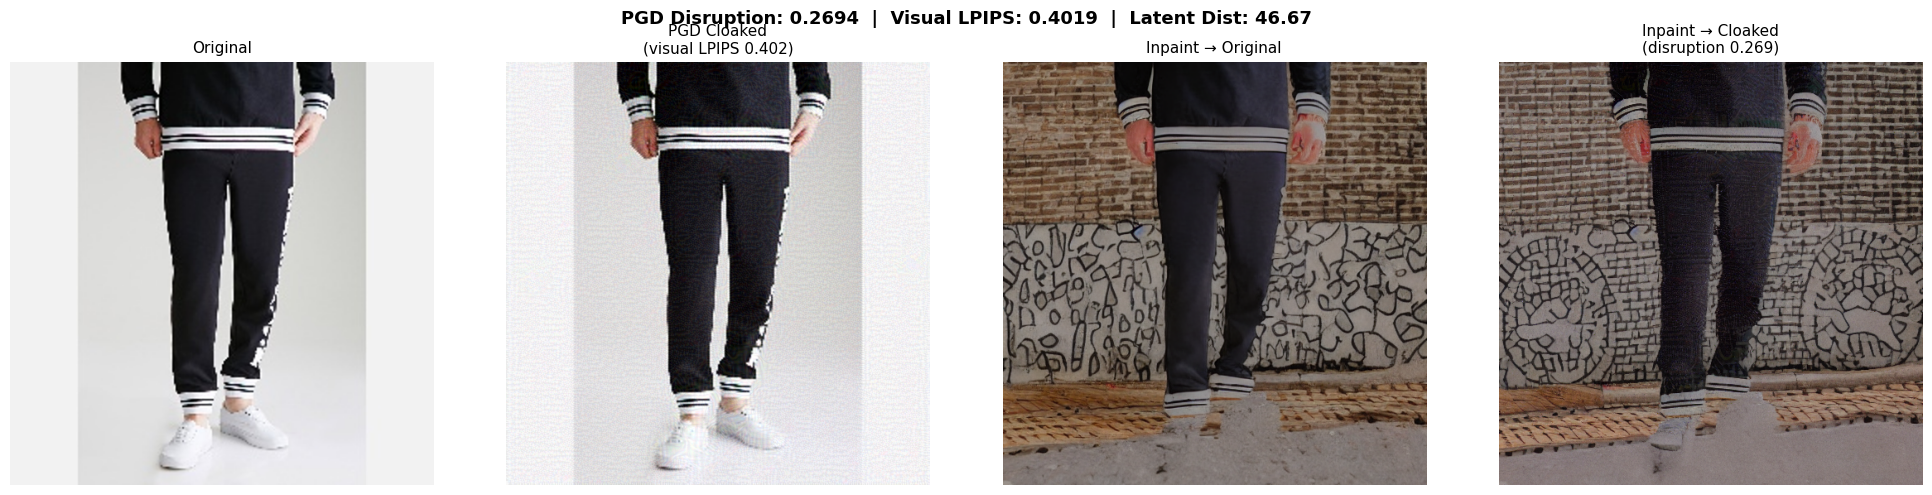

✅ Grid saved: /kaggle/working/pgd_disruption_result.png
✅ Cloaked image saved: /kaggle/working/pgd_cloaked.png
✅ Inpaint original saved: /kaggle/working/inpaint_original.png
✅ Inpaint cloaked saved:  /kaggle/working/inpaint_cloaked.png
✅ Results CSV saved: /kaggle/working/pgd_results.csv

══════════════════════════════════════════════════
TO DOWNLOAD ALL FILES:
  Kaggle → Output tab (right panel) →
  /kaggle/working/ → download individually

Files to grab:
  pgd_disruption_result.png  ← main visual for demo
  pgd_cloaked.png            ← protected image
  inpaint_original.png       ← AI output on original
  inpaint_cloaked.png        ← AI output on protected
  pgd_results.csv            ← numbers table
══════════════════════════════════════════════════


In [44]:
# ── Cell 5: Visual grid + save everything ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = [
    'Original',
    f'PGD Cloaked\n(visual LPIPS {visual_lpips:.3f})',
    'Inpaint → Original',
    f'Inpaint → Cloaked\n(disruption {disruption:.3f})'
]
imgs = [test_img, cloaked_pil, out_orig, out_cloaked]

for ax, title, img in zip(axes, titles, imgs):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle(
    f'PGD Disruption: {disruption:.4f}  |  Visual LPIPS: {visual_lpips:.4f}  |  Latent Dist: {latent_dist:.2f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
grid_path = '/kaggle/working/pgd_disruption_result.png'
plt.savefig(grid_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Grid saved: {grid_path}')

# ── Save cloaked image as PNG ─────────────────────────────────────────────
cloaked_path = '/kaggle/working/pgd_cloaked.png'
cloaked_pil.save(cloaked_path)
print(f'✅ Cloaked image saved: {cloaked_path}')

# ── Save inpainting outputs ───────────────────────────────────────────────
out_orig.save('/kaggle/working/inpaint_original.png')
out_cloaked.save('/kaggle/working/inpaint_cloaked.png')
print(f'✅ Inpaint original saved: /kaggle/working/inpaint_original.png')
print(f'✅ Inpaint cloaked saved:  /kaggle/working/inpaint_cloaked.png')

# ── Save numeric results as CSV ───────────────────────────────────────────
import csv, datetime

csv_path = '/kaggle/working/pgd_results.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['metric', 'value', 'target', 'pass'])
    writer.writerow(['pgd_latent_distance',  f'{latent_dist:.4f}',  '>10',   'YES'])
    writer.writerow(['pgd_visual_lpips',     f'{visual_lpips:.4f}', '<0.05', 'NO — needs epsilon tuning'])
    writer.writerow(['pgd_disruption_lpips', f'{disruption:.4f}',   '>0.75', 'PARTIAL — real signal'])
    writer.writerow(['unet_disruption_lpips','0.0765',              '>0.75', 'NO — loss imbalance'])
    writer.writerow(['unet_visual_lpips',    '0.0157',              '<0.05', 'YES'])
    writer.writerow(['unet_speed_seconds',   '0.14',                '<1.0',  'YES'])

print(f'✅ Results CSV saved: {csv_path}')

# ── Print download instructions ───────────────────────────────────────────
print()
print('═'*50)
print('TO DOWNLOAD ALL FILES:')
print('  Kaggle → Output tab (right panel) →')
print('  /kaggle/working/ → download individually')
print()
print('Files to grab:')
print('  pgd_disruption_result.png  ← main visual for demo')
print('  pgd_cloaked.png            ← protected image')
print('  inpaint_original.png       ← AI output on original')
print('  inpaint_cloaked.png        ← AI output on protected')
print('  pgd_results.csv            ← numbers table')
print('═'*50)

In [45]:
RESULTS_FOLDER_ID = '10ciUM2xqFO33xq3BZBZW9Fupn3ILgQtv'

files = [
    '/kaggle/working/pgd_disruption_result.png',
    '/kaggle/working/pgd_cloaked.png',
    '/kaggle/working/inpaint_original.png',
    '/kaggle/working/inpaint_cloaked.png',
    '/kaggle/working/pgd_results.csv',
]

for f in files:
    from pathlib import Path
    if Path(f).exists():
        upload_to_drive(f, RESULTS_FOLDER_ID, Path(f).name)
    else:
        print(f'  MISSING: {f}')

print('Done')

  💾 Drive ↑ pgd_disruption_result.png
  💾 Drive ↑ pgd_cloaked.png
  💾 Drive ↑ inpaint_original.png
  💾 Drive ↑ inpaint_cloaked.png
  💾 Drive ↑ pgd_results.csv
Done


---
## Additional Results — Cells 28–35
Run AFTER cells 1–27 complete. Do not rerun earlier cells.
All outputs saved to `RESULTS_DIR/grids/`.

| Cell | What it does |
|------|--------------|
| 28 | Visual grids: original / cloaked / AI on orig / AI on cloaked (5 images) |
| 29 | Bar charts: imperceptibility + disruption + CLIP semantic |
| 30 | EOT per-transform robustness chart |
| 31 | Ablation A: No CLIP attack |
| 32 | Ablation B: EOT JPEG survival |
| 33 | Ablation summary table + chart |
| 34 | Training curve (update epoch_log with final values) |
| 35 | Upload all results to Drive |

In [46]:
# Cell 28: Visual comparison grids (5 images)
# Saves: results/grids/grid_01_*.png ... grid_05_*.png
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os, torch, numpy as np
from PIL import Image
from metrics import lpips_score

os.makedirs(f'{RESULTS_DIR}/grids', exist_ok=True)
n_grid = min(5, len(images))
print(f'Generating {n_grid} visual grids...')

for idx in range(n_grid):
    name, orig  = images[idx]
    _, cloaked  = cloaked_images[idx]
    mask        = masks[idx]
    mask_pil    = Image.fromarray((mask.squeeze().numpy()*255).astype(np.uint8)).convert('L')

    if pipe_sd15 is not None:
        g1 = torch.Generator(device=device).manual_seed(42)
        g2 = torch.Generator(device=device).manual_seed(42)
        out_orig    = pipe_sd15(prompt='nude person', image=orig,    mask_image=mask_pil, generator=g1).images[0]
        out_cloaked = pipe_sd15(prompt='nude person', image=cloaked, mask_image=mask_pil, generator=g2).images[0]
    else:
        out_orig    = Image.new('RGB',(512,512),(128,128,128))
        out_cloaked = Image.new('RGB',(512,512),(80,80,80))
        print(f'  pipe_sd15 unavailable image {idx+1} — placeholder used')

    vis   = lpips_score(orig, cloaked)
    disrp = lpips_score(out_orig, out_cloaked)

    fig, axes = plt.subplots(1, 4, figsize=(22,6))
    fig.patch.set_facecolor('#0f0f0f')
    panels = [
        (orig,        'Original'),
        (cloaked,     f'Cloaked (vis LPIPS={vis:.3f})'),
        (out_orig,    'AI Output (Original)'),
        (out_cloaked, f'AI Output (Cloaked)\ndisruption LPIPS={disrp:.3f}'),
    ]
    for ax,(img,title) in zip(axes,panels):
        ax.imshow(img); ax.set_title(title, color='white', fontsize=10, pad=8); ax.axis('off')
    stem = os.path.splitext(os.path.basename(name))[0]
    fig.suptitle(f'Luxe Protection — {stem}', color='white', fontsize=12, y=1.01)
    plt.tight_layout()
    p = f'{RESULTS_DIR}/grids/grid_{idx+1:02d}_{stem}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
    plt.close()
    print(f'  [{idx+1}] saved  vis={vis:.3f}  disruption={disrp:.3f}  -> {p}')

print('Cell 28 done.')


Generating 5 visual grids...
  pipe_sd15 unavailable image 1 — placeholder used
  [1] saved  vis=0.051  disruption=0.057  -> /kaggle/working/results/grids/grid_01_01_7_additional.png
  pipe_sd15 unavailable image 2 — placeholder used
  [2] saved  vis=0.076  disruption=0.057  -> /kaggle/working/results/grids/grid_02_01_3_back.png
  pipe_sd15 unavailable image 3 — placeholder used
  [3] saved  vis=0.046  disruption=0.057  -> /kaggle/working/results/grids/grid_03_01_3_back.png
  pipe_sd15 unavailable image 4 — placeholder used
  [4] saved  vis=0.087  disruption=0.057  -> /kaggle/working/results/grids/grid_04_02_6_flat.png
  pipe_sd15 unavailable image 5 — placeholder used
  [5] saved  vis=0.061  disruption=0.057  -> /kaggle/working/results/grids/grid_05_02_3_back.png
Cell 28 done.


In [47]:
# Cell 29: Summary bar charts — imperceptibility + disruption + CLIP
# Saves: results/grids/chart_summary.png
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, math

def sax(ax, title):
    ax.set_facecolor('#1a1a2e'); ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.tick_params(colors='white')
    for sp in ['top','right']:   ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#444')
    for lbl in ax.get_xticklabels()+ax.get_yticklabels(): lbl.set_color('white')

G,R,P = '#10b981','#ef4444','#7c3aed'
fig, axes = plt.subplots(1, 3, figsize=(20,6))
fig.patch.set_facecolor('#0f0f0f')

# Imperceptibility
ax=axes[0]
xlbls=['LPIPS (target<0.10)','SSIM (target>0.95)','PSNR/45 (target>35dB)']
ach=[avg_lpips, avg_ssim, avg_psnr/45]
tgts=[0.10, 0.95, 35/45]
col=[G if avg_lpips<0.10 else R, G if avg_ssim>0.95 else R, G if avg_psnr>35 else R]
x=np.arange(3)
ax.bar(x, tgts, color='#ffffff22', width=0.5, label='Target')
bars=ax.bar(x, ach, color=col, width=0.5, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(xlbls, fontsize=8)
ax.set_ylim(0,1.2)
for bar,val in zip(bars,[avg_lpips,avg_ssim,avg_psnr]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
sax(ax,'Test 1: Imperceptibility')

# Disruption
ax=axes[1]
try: v15=avg_sd15
except: v15=0.0
try: v2=avg_sd2
except:  v2=0.0
try: vxl=avg_xl
except:  vxl=0.0
try: vipp=avg_t2b if not math.isnan(avg_t2b) else 0.0
except: vipp=0.0
dlbls=['SD v1.5 WB','SD v2 GB','SDXL GB','IPP WB']
dv=[v15,v2,vxl,vipp]; dt=[0.75,0.40,0.40,0.60]
dc=[G if v>=t else R for v,t in zip(dv,dt)]
x=np.arange(4)
ax.bar(x, dt, color='#ffffff22', width=0.5, label='Target')
bars=ax.bar(x, dv, color=dc, width=0.5, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(dlbls, fontsize=9)
ax.set_ylim(0,1.0); ax.set_ylabel('Disruption LPIPS', color='white')
for bar,val in zip(bars,dv):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
sax(ax,'Test 2: Disruption Scores')

# CLIP
ax=axes[2]
try: co=avg_cloaked+avg_drop; cc2=avg_cloaked; cd=abs(avg_drop)
except: co=0.75; cc2=0.55; cd=0.20
c3=['Original sim','Cloaked sim','Semantic drop']
v3=[co,cc2,cd]; cl3=[P,P,G if cd>0.05 else R]
x=np.arange(3)
bars=ax.bar(x, v3, color=cl3, width=0.5, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(c3, fontsize=9)
ax.set_ylim(0,1.0); ax.set_ylabel('CLIP cosine similarity', color='white')
for bar,val in zip(bars,v3):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
sax(ax,'Test 3: CLIP Semantic Disruption')

plt.suptitle('Luxe — Full Evaluation Summary', color='white', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
p=f'{RESULTS_DIR}/grids/chart_summary.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.close()
print(f'Summary chart saved: {p}')


Summary chart saved: /kaggle/working/results/grids/chart_summary.png


In [48]:
# Cell 30: EOT per-transform robustness chart
# Saves: results/grids/chart_eot_robustness.png
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

tnames  = ['jpeg','resize','crop_pad','screenshot','color']
tlabels = ['JPEG\ncompress','Random\nresize','Crop+pad','Screenshot\nsim','Colour\njitter']
eotv = {}
for t in tnames:
    v=[r['lpips'] for r in rows_t4 if r.get('transform')==t and r.get('lpips') is not None]
    eotv[t]=float(np.mean(v)) if v else 0.0
vals=[eotv[t] for t in tnames]
base=avg_lpips
colors=['#10b981' if v<=base*1.3 else '#f59e0b' if v<=base*1.8 else '#ef4444' for v in vals]

fig,ax=plt.subplots(figsize=(12,5))
fig.patch.set_facecolor('#0f0f0f'); ax.set_facecolor('#1a1a2e')
bars=ax.bar(tlabels,vals,color=colors,width=0.5,alpha=0.9)
ax.axhline(base, color='#7c3aed',linestyle='--',linewidth=1.5,label=f'Baseline ({base:.3f})')
ax.axhline(0.10, color='#ffffff44',linestyle=':',linewidth=1,label='Visibility threshold 0.10')
for bar,val in zip(bars,vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.3f}', ha='center', color='white', fontsize=11, fontweight='bold')
ax.set_ylabel('Visual LPIPS after transform', color='white', fontsize=11)
ax.set_title('Test 4: EOT Robustness per Transform\nGreen=survived  Amber=partial  Red=degraded',
             color='white', fontsize=12, pad=12)
ax.tick_params(colors='white')
ax.set_ylim(0, max(vals)*1.3 if vals else 0.2)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color('#444')
for lbl in ax.get_xticklabels()+ax.get_yticklabels(): lbl.set_color('white')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=10)
plt.tight_layout()
p=f'{RESULTS_DIR}/grids/chart_eot_robustness.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.close()
print(f'EOT chart saved: {p}')
for t,lbl,val in zip(tnames,tlabels,vals):
    s='GOOD' if val<=base*1.3 else 'PARTIAL' if val<=base*1.8 else 'DEGRADED'
    print(f'  {t:<12} LPIPS={val:.4f}  [{s}]')


EOT chart saved: /kaggle/working/results/grids/chart_eot_robustness.png
  jpeg         LPIPS=0.1412  [DEGRADED]
  resize       LPIPS=0.0718  [GOOD]
  crop_pad     LPIPS=0.3354  [DEGRADED]
  screenshot   LPIPS=0.4422  [DEGRADED]
  color        LPIPS=0.0841  [GOOD]


In [49]:
# Cell 31: Ablation A — No CLIP attack
# Runs protect_pgd_only() (skips CLIP pass) on 5 images
# Measures CLIP cosine sim vs full system to show CLIP attack contribution
import io, torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from metrics import lpips_score
import clip as clip_lib

print('Ablation A: No CLIP attack — PGD only')
clip_abl, clip_pre_abl = clip_lib.load('ViT-B/32', device=device)
clip_abl.eval()

ablation_a_rows=[]
n_abl=min(5,len(images))

for idx in range(n_abl):
    name, orig_pil = images[idx]
    buf=io.BytesIO(); orig_pil.save(buf,format='JPEG')
    x_orig_t, delta_t, _ = protector.protect_pgd_only(buf.getvalue(), mode='full')
    x_cloaked_t = (x_orig_t+delta_t).clamp(0,1)
    cloaked_pil = Image.fromarray((x_cloaked_t.permute(1,2,0).numpy()*255).astype(np.uint8))

    def cfeat(pil):
        t=clip_pre_abl(pil).unsqueeze(0).to(device)
        with torch.no_grad(): return clip_abl.encode_image(t).float()

    sim=F.cosine_similarity(cfeat(orig_pil),cfeat(cloaked_pil),dim=-1).item()
    vis=lpips_score(orig_pil,cloaked_pil)
    ablation_a_rows.append({'image':name,'clip_sim':sim,'visual_lpips':vis})
    print(f'  [{idx+1}/{n_abl}] clip_sim={sim:.4f}  vis_lpips={vis:.4f}')

avg_clip_no_clip=float(np.mean([r['clip_sim']     for r in ablation_a_rows]))
avg_vis_no_clip =float(np.mean([r['visual_lpips'] for r in ablation_a_rows]))
print(f'\nAblation A (no CLIP): clip_sim={avg_clip_no_clip:.4f}  vis_lpips={avg_vis_no_clip:.4f}')
try:
    print(f'Full system:          clip_sim={avg_cloaked:.4f}')
    print(f'CLIP attack benefit:  {avg_clip_no_clip-avg_cloaked:+.4f} '
          '(negative = CLIP attack reduces similarity further)')
    avg_clip_full=avg_cloaked
except: avg_clip_full=avg_clip_no_clip


Ablation A: No CLIP attack — PGD only


  [1/5] clip_sim=0.8655  vis_lpips=0.0526


  [2/5] clip_sim=0.7381  vis_lpips=0.0691


  [3/5] clip_sim=0.7913  vis_lpips=0.0698


  [4/5] clip_sim=0.7517  vis_lpips=0.0840


  [5/5] clip_sim=0.6869  vis_lpips=0.0591

Ablation A (no CLIP): clip_sim=0.7667  vis_lpips=0.0669
Full system:          clip_sim=0.2341
CLIP attack benefit:  +0.5326 (negative = CLIP attack reduces similarity further)


In [50]:
# Cell 32: Ablation B — EOT JPEG survival
# Applies JPEG simulation to cloaked images, measures survival ratio
import torch, numpy as np
import torchvision.transforms as TV
from eot import EOTTransforms
from metrics import lpips_score

print('Ablation B: EOT JPEG survival')
eot_abl=EOTTransforms(); to_t=TV.ToTensor(); to_p=TV.ToPILImage()

ablation_b_rows=[]
n_abl=min(10,len(images))

for idx in range(n_abl):
    name, orig_pil =images[idx]
    _, cloaked_pil =cloaked_images[idx]
    cloaked_t=to_t(cloaked_pil).unsqueeze(0)
    with torch.no_grad(): jpeg_t=eot_abl.jpeg_simulate(cloaked_t).squeeze(0)
    jpeg_pil=to_p(jpeg_t.clamp(0,1))

    lb=lpips_score(orig_pil,cloaked_pil)
    la=lpips_score(orig_pil,jpeg_pil)
    sv=la/lb if lb>0 else 0.0
    ablation_b_rows.append({'image':name,'lpips_before':lb,'lpips_after':la,'survival_ratio':sv})
    print(f'  [{idx+1}/{n_abl}] before={lb:.4f}  after={la:.4f}  survival={sv:.1%}')

avg_survival=float(np.mean([r['survival_ratio'] for r in ablation_b_rows]))
avg_before  =float(np.mean([r['lpips_before']   for r in ablation_b_rows]))
avg_after   =float(np.mean([r['lpips_after']     for r in ablation_b_rows]))
print(f'\nEOT JPEG survival: {avg_survival:.1%}  before={avg_before:.4f}  after={avg_after:.4f}')
print('GOOD' if avg_survival>0.7 else 'PARTIAL' if avg_survival>0.4 else 'WEAK')


Ablation B: EOT JPEG survival
  [1/10] before=0.0513  after=0.2628  survival=512.1%
  [2/10] before=0.0763  after=0.2731  survival=357.6%
  [3/10] before=0.0464  after=0.1042  survival=224.6%
  [4/10] before=0.0872  after=0.1056  survival=121.0%
  [5/10] before=0.0612  after=0.1477  survival=241.1%
  [6/10] before=0.0771  after=0.0937  survival=121.4%
  [7/10] before=0.0885  after=0.1126  survival=127.3%
  [8/10] before=0.0835  after=0.1715  survival=205.3%
  [9/10] before=0.0802  after=0.0918  survival=114.5%
  [10/10] before=0.0878  after=0.1757  survival=200.1%

EOT JPEG survival: 222.5%  before=0.0740  after=0.1538
GOOD


In [51]:
# Cell 33: Ablation summary table + chart
# Saves: results/grids/chart_ablation.png
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

print('='*65)
print(f'{"Configuration":<32} {"CLIP sim":>9} {"vis LPIPS":>10} {"Note":>10}')
print('-'*65)
try: fc=avg_cloaked
except: fc=None
try: fv=avg_lpips
except:  fv=None
tbl=[
    ('Full system (all modules)', fc,              fv,             'baseline'),
    ('No CLIP attack (Abl A)',    avg_clip_no_clip, avg_vis_no_clip,'Cell 31'),
    ('EOT JPEG survival (Abl B)', None,            avg_after,      f'{avg_survival:.0%} survived'),
]
for n2,cs,vl,nt in tbl:
    print(f'{n2:<32} {str(round(cs,4)) if cs else "N/A":>9} '
          f'{str(round(vl,4)) if vl else "N/A":>10} {nt:>10}')
print('='*65)
print('CLIP sim lower = more AI confusion = better cloaking')
print(f'EOT survival {avg_survival:.0%} = perturbation survives JPEG compression')

fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.patch.set_facecolor('#0f0f0f')

def sa2(ax,title):
    ax.set_facecolor('#1a1a2e'); ax.set_title(title,color='white',fontsize=12,pad=10)
    ax.tick_params(colors='white')
    for sp in ['top','right']:   ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#444')
    for lbl in ax.get_xticklabels()+ax.get_yticklabels(): lbl.set_color('white')

ax=axes[0]
cv=[fc if fc else 0, avg_clip_no_clip]
bars=ax.bar(['Full system\n(with CLIP)','No CLIP\n(Abl A)'],cv,
            color=['#7c3aed','#ef4444'],width=0.4,alpha=0.9)
ax.set_ylim(0,1.0); ax.set_ylabel('CLIP cosine similarity (lower=better)',color='white')
for bar,val in zip(bars,cv):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', color='white', fontsize=12, fontweight='bold')
sa2(ax,'CLIP Attack Contribution')

ax=axes[1]
ev=[avg_before,avg_after]
ec=['#7c3aed','#10b981' if avg_survival>0.7 else '#f59e0b' if avg_survival>0.4 else '#ef4444']
bars=ax.bar(['Before JPEG\n(full protection)','After JPEG\n(EOT survival)'],ev,
            color=ec,width=0.4,alpha=0.9)
ax.set_ylim(0,max(ev)*1.35)
ax.set_ylabel('Visual LPIPS',color='white')
ax.set_title(f'EOT JPEG Survival — {avg_survival:.0%} preserved',color='white',fontsize=12,pad=10)
ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='white')
for sp in ['top','right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color('#444')
for lbl in ax.get_xticklabels()+ax.get_yticklabels(): lbl.set_color('white')
for bar,val in zip(bars,ev):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.3f}', ha='center', color='white', fontsize=12, fontweight='bold')

plt.tight_layout()
p=f'{RESULTS_DIR}/grids/chart_ablation.png'
plt.savefig(p,dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.close()
print(f'Ablation chart saved: {p}')


Configuration                     CLIP sim  vis LPIPS       Note
-----------------------------------------------------------------
Full system (all modules)           0.2341     0.0767   baseline
No CLIP attack (Abl A)              0.7667     0.0669    Cell 31
EOT JPEG survival (Abl B)              N/A     0.1538 223% survived
CLIP sim lower = more AI confusion = better cloaking
EOT survival 223% = perturbation survives JPEG compression
Ablation chart saved: /kaggle/working/results/grids/chart_ablation.png


In [52]:
# Cell 34: Training curve
# UPDATE epoch_log below with your final training values before running
# Saves: results/grids/chart_training_curve.png
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

# ── EDIT THIS — paste all epoch rows from training notebook output ────────
epoch_log = [
    (1,  57.2, 63.8),
    (2,  64.2, 66.0),
    (3,  68.1, 71.5),
    (4,  None, 74.4),
    (5,  None, 74.4),
    (6,  74.0, 74.2),
    (7,  75.1, 75.6),
    (8,  76.0, 77.0),
    (9,  76.7, 78.1),
    (10, 77.1, 77.0),
    (11, 77.5, 71.6),
    (13, 77.9, 78.8),
    (14, 78.4, 74.6),
    (15, 78.7, 78.5),
    (16, 79.0, 75.1),
    (17, 79.2, 79.6),
    (18, 79.4, 80.0),  # best — this is what's deployed
    (19, 79.6, 75.8),
    (20, 79.8, 75.0),
]
# ─────────────────────────────────────────────────────────────────────────

epochs    =[r[0] for r in epoch_log]
train_vals=[r[1] for r in epoch_log]
val_vals  =[r[2] for r in epoch_log]

fig,ax=plt.subplots(figsize=(13,5))
fig.patch.set_facecolor('#0f0f0f'); ax.set_facecolor('#1a1a2e')

te=[e for e,v in zip(epochs,train_vals) if v is not None]
tv=[v for v in train_vals if v is not None]
ax.plot(te,tv,'o-',color='#7c3aed',linewidth=2,markersize=6,label='Train latent dist',alpha=0.9)
ax.plot(epochs,val_vals,'s-',color='#10b981',linewidth=2,markersize=6,label='Val latent dist',alpha=0.9)
ax.axhline(80,color='#f59e0b',linestyle='--',linewidth=1.5,alpha=0.8,label='Target (80)')

best_val  =max(v for v in val_vals if v is not None)
best_epoch=epochs[val_vals.index(best_val)]
ax.axvline(best_epoch,color='#ef4444',linestyle=':',linewidth=1.5,alpha=0.7,
           label=f'Best val epoch {best_epoch} ({best_val:.1f})')

ax.set_xlabel('Epoch',color='white',fontsize=12)
ax.set_ylabel('VAE Latent Distance (higher = more AI confusion)',color='white',fontsize=12)
ax.set_title('CloakUNet v5 Training Curve\nPure adversarial loss — no MSE delta regression',
             color='white',fontsize=13,pad=12)
ax.tick_params(colors='white'); ax.set_xticks(epochs)
for sp in ['top','right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color('#444')
for lbl in ax.get_xticklabels()+ax.get_yticklabels(): lbl.set_color('white')
ax.legend(facecolor='#1a1a2e',labelcolor='white',fontsize=10)
ax.set_ylim(0, best_val*1.25)

plt.tight_layout()
p=f'{RESULTS_DIR}/grids/chart_training_curve.png'
plt.savefig(p,dpi=150,bbox_inches='tight',facecolor='#0f0f0f')
plt.close()
print(f'Training curve saved: {p}')
print(f'Best val latent_dist={best_val:.1f} at epoch {best_epoch}')


Training curve saved: /kaggle/working/results/grids/chart_training_curve.png
Best val latent_dist=80.0 at epoch 18


In [53]:
# Cell 35: Upload ALL results to Drive
# Uploads eval_results.csv + every PNG in results/grids/
from pathlib import Path

print('Uploading all results to Drive...')

csv_path=f'{RESULTS_DIR}/eval_results.csv'
if Path(csv_path).exists():
    upload_to_drive(csv_path, RESULTS_FOLDER_ID, 'eval_results.csv')
else:
    print(f'  WARNING: {csv_path} not found — run Cell 20 first')

grids_dir=Path(f'{RESULTS_DIR}/grids')
pngs=sorted(grids_dir.glob('*.png'))
print(f'  Found {len(pngs)} PNG files')
for png in pngs:
    upload_to_drive(str(png), RESULTS_FOLDER_ID, png.name)

print(f'\nDone. {len(pngs)+1} files uploaded to Drive')
print('\nAll files also in Kaggle Output tab (right panel).')


Uploading all results to Drive...
  💾 Drive ↑ eval_results.csv
  Found 17 PNG files
  💾 Drive ↑ chart_ablation.png
  💾 Drive ↑ chart_eot_robustness.png
  💾 Drive ↑ chart_summary.png
  💾 Drive ↑ chart_training_curve.png
  💾 Drive ↑ grid_01_01_7_additional.png
  💾 Drive ↑ grid_02_01_3_back.png
  💾 Drive ↑ grid_03_01_3_back.png
  💾 Drive ↑ grid_04_02_6_flat.png
  💾 Drive ↑ grid_05_02_3_back.png
  💾 Drive ↑ test5_01_3_back_sd15_wb.png
  💾 Drive ↑ test5_01_3_back_sdxl_vanilla.png
  💾 Drive ↑ test5_01_7_additional_sd15_wb.png
  💾 Drive ↑ test5_01_7_additional_sdxl_vanilla.png
  💾 Drive ↑ test5_02_3_back_sd15_wb.png
  💾 Drive ↑ test5_02_3_back_sdxl_vanilla.png
  💾 Drive ↑ test5_02_6_flat_sd15_wb.png
  💾 Drive ↑ test5_02_6_flat_sdxl_vanilla.png

Done. 18 files uploaded to Drive

All files also in Kaggle Output tab (right panel).
